In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D,Flatten
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from matplotlib.ticker import MultipleLocator, FormatStrFormatter

In [ ]:
(X_train,y_train),(X_test,y_test)=cifar10.load_data()
print(X_train.shape)
print(X_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


In [ ]:
X_train.dtype

dtype('uint8')

In [ ]:
X_train=X_train.astype(float)/255
X_test=X_test.astype(float)/255

In [ ]:
y_train[0]

array([6], dtype=uint8)

In [ ]:
y_train=to_categorical(y_train)
y_test=to_categorical(y_test)


In [ ]:
y_train[0]

array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0.])

In [ ]:
model=Sequential()

model.add(Conv2D(filters=64,kernel_size=(3,3),padding='same',activation='relu',input_shape=(32,32,3)))
model.add(Conv2D(filters=32,kernel_size=(3,3),padding='same',activation='relu',input_shape=(32,32,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(filters=64,kernel_size=(3,3),padding='same',activation='relu',input_shape=(32,32,3)))
model.add(Conv2D(filters=128,kernel_size=(3,3),padding='same',activation='relu',input_shape=(32,32,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(filters=256,kernel_size=(3,3),padding='same',activation='relu',input_shape=(32,32,3)))
model.add(Conv2D(filters=32,kernel_size=(3,3),padding='same',activation='relu',input_shape=(32,32,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(units=1024,activation='relu'))
model.add(Dense(units=512,activation='relu'))
model.add(Dense(units=10,activation='softmax'))

model.compile(loss='categorical_crossentropy',metrics=['accuracy'],optimizer='rmsprop')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 32)       │        73,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,536,778 (5.86 MB)

 Trainable params: 1,536,778 (5.86 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
first_model=model.fit(X_train,y_train,epochs=25,batch_size=256,validation_split=0.25)

Epoch 1/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 21s 88ms/step - accuracy: 0.1563 - loss: 2.2847 - val_accuracy: 0.2731 - val_loss: 1.9577
Epoch 2/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.3117 - loss: 1.9015 - val_accuracy: 0.4019 - val_loss: 1.6517
Epoch 3/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.4199 - loss: 1.6047 - val_accuracy: 0.4616 - val_loss: 1.4701
Epoch 4/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.4901 - loss: 1.4311 - val_accuracy: 0.4946 - val_loss: 1.4092
Epoch 5/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.5620 - loss: 1.2328 - val_accuracy: 0.4782 - val_loss: 1.4751
Epoch 6/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.6024 - loss: 1.1107 - val_accuracy: 0.5593 - val_loss: 1.2763
Epoch 7/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.6571 - loss: 0.9721 - val_accuracy: 0.6473 - val_loss: 1.0276
Epoch 8/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.7041 - loss: 0.8362 - val_ac

In [ ]:
def plotter(history,title,first,second,first_label,second_label):
  plt.plot(history[first],label=first_label)
  plt.plot(history[second],label=second_label)
  plt.title(title)
  plt.xlabel('epochs')
  plt.ylabel(first)
  plt.legend()
  plt.show()

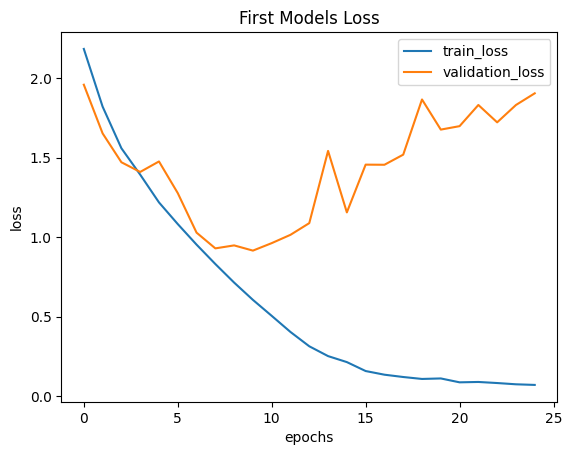

In [ ]:
plotter(first_model.history,'First Models Loss','loss','val_loss','train_loss','validation_loss')

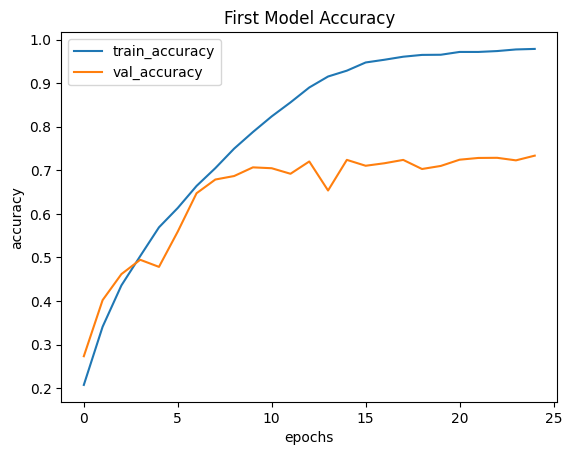

In [ ]:
plotter(first_model.history,'First Model Accuracy','accuracy','val_accuracy','train_accuracy','val_accuracy')

In [16]:
second_model=Sequential()

second_model.add(Conv2D(filters=64,kernel_size=(3,3),padding='same',activation='relu',input_shape=(32,32,3)))
second_model.add(Conv2D(filters=32,kernel_size=(3,3),padding='same',activation='relu',input_shape=(32,32,3)))
second_model.add(MaxPooling2D(pool_size=(2,2)))
second_model.add(Dropout(0.35))

second_model.add(Conv2D(filters=64,kernel_size=(3,3),padding='same',activation='relu',input_shape=(32,32,3)))
second_model.add(Conv2D(filters=128,kernel_size=(3,3),padding='same',activation='relu',input_shape=(32,32,3)))
second_model.add(MaxPooling2D(pool_size=(2,2)))
second_model.add(Dropout(0.25))

second_model.add(Conv2D(filters=256,kernel_size=(3,3),padding='same',activation='relu',input_shape=(32,32,3)))
second_model.add(Conv2D(filters=32,kernel_size=(3,3),padding='same',activation='relu',input_shape=(32,32,3)))
second_model.add(MaxPooling2D(pool_size=(2,2)))
second_model.add(Dropout(0.25))

second_model.add(Flatten())
second_model.add(Dense(units=1024,activation='relu'))
second_model.add(Dropout(0.5))
second_model.add(Dense(units=512,activation='relu'))
second_model.add(Dropout(0.75))
second_model.add(Dense(units=10,activation='softmax'))

second_model.compile(loss='categorical_crossentropy',metrics=['accuracy'],optimizer='rmsprop')
second_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 32)       │        73,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,536,778 (5.86 MB)

 Trainable params: 1,536,778 (5.86 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
second_model_hist=second_model.fit(X_train,y_train,epochs=25,batch_size=256,validation_split=0.35)

Epoch 1/25
127/127 ━━━━━━━━━━━━━━━━━━━━ 26s 142ms/step - accuracy: 0.1082 - loss: 2.3071 - val_accuracy: 0.2213 - val_loss: 2.1196
Epoch 2/25
127/127 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.2048 - loss: 2.1428 - val_accuracy: 0.3033 - val_loss: 1.9038
Epoch 3/25
127/127 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.2890 - loss: 1.9191 - val_accuracy: 0.3779 - val_loss: 1.6849
Epoch 4/25
127/127 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.3598 - loss: 1.7408 - val_accuracy: 0.4336 - val_loss: 1.5226
Epoch 5/25
127/127 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.4117 - loss: 1.6191 - val_accuracy: 0.4753 - val_loss: 1.4322
Epoch 6/25
127/127 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.4516 - loss: 1.4959 - val_accuracy: 0.5309 - val_loss: 1.2933
Epoch 7/25
127/127 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.4845 - loss: 1.4131 - val_accuracy: 0.4882 - val_loss: 1.3694
Epoch 8/25
127/127 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.5198 - loss: 1.3370 - val_ac

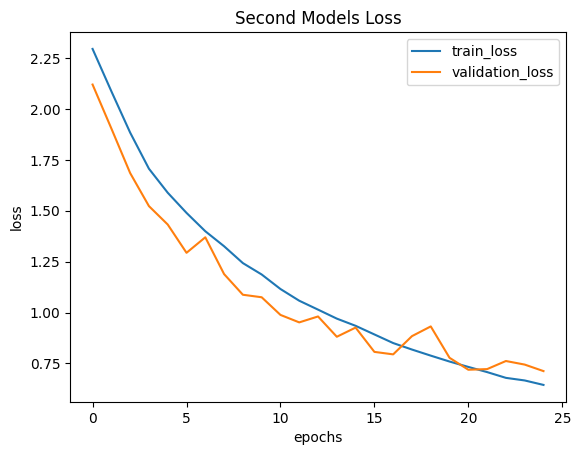

In [18]:
plotter(second_model_hist.history,'Second Models Loss','loss','val_loss','train_loss','validation_loss')

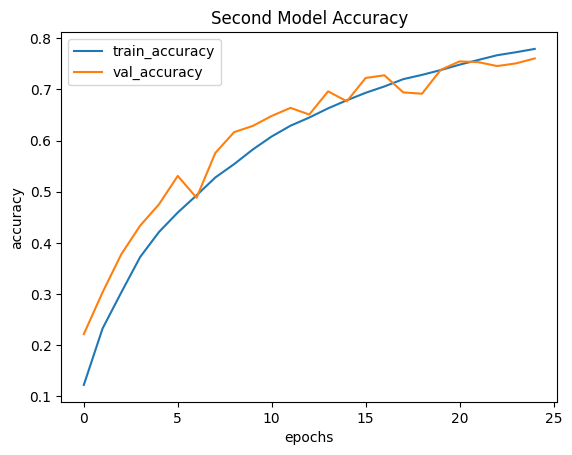

In [19]:
plotter(second_model_hist.history,'Second Model Accuracy','accuracy','val_accuracy','train_accuracy','val_accuracy')

In [41]:
y_pred=second_model.predict(X_test[:10])
y_pred.argmax(axis=1)
y_pred.shape
y_pred[1].argmax()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


np.int64(8)

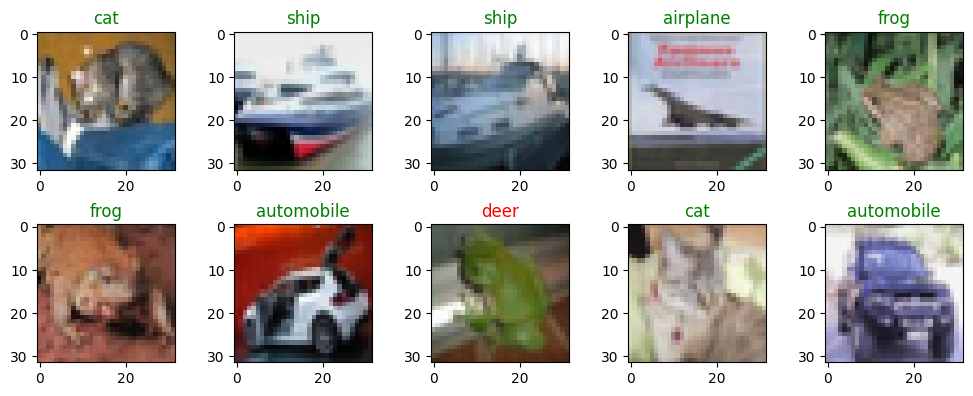

In [42]:
class_names = [
        "airplane",
        "automobile",
        "bird",
        "cat",
        "deer",
        "dog",
        "frog",
        "horse",
        "ship",
        "truck",
]
plt.figure(figsize=(10,4))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(X_test[i])
  col='red'
  if y_pred[i].argmax(axis=0)==y_test[i].argmax(axis=0):
    col='green'
  plt.title(class_names[y_pred[i].argmax(axis=0)],color=col)
plt.tight_layout()
plt.show()